In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

print(f"pandas:{pd.__version__}")
print(f"yfinance{yf.__version__}")
print ("工具就绪，开始做量化")

Matplotlib is building the font cache; this may take a moment.


pandas:3.0.2
yfinance1.3.0
工具就绪，开始做量化


## 1.下载SPY历史数据

In [3]:
spy = yf.download("spy",period='1y',auto_adjust=True)

print(f"数据类型:{type(spy)}")
print(f"数据形状:{spy.shape}")
print(f"日期范围:{spy.index[0].date()}→ {spy.index[-1].date()}")
spy.head()

[*********************100%***********************]  1 of 1 completed

数据类型:<class 'pandas.DataFrame'>
数据形状:(251, 5)
日期范围:2025-04-23→ 2026-04-22


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2025-04-23,529.351685,539.248244,527.829160,534.304912,90590700
2025-04-24,540.494080,541.225683,529.381478,530.637043,64150400
2025-04-25,544.399231,544.804558,537.527988,540.454462,61119600
2025-04-28,544.606873,547.276284,538.842991,545.140791,47613800
2025-04-29,548.037537,549.154734,542.332912,542.688818,47775100


In [4]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-04-23 to 2026-04-22
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   251 non-null    float64
 1   (High, SPY)    251 non-null    float64
 2   (Low, SPY)     251 non-null    float64
 3   (Open, SPY)    251 non-null    float64
 4   (Volume, SPY)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [5]:
spy.describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,647.712447,650.501206,644.197480,647.439333,7.679827e+07
std,40.376810,40.495566,40.463285,40.659817,2.152505e+07
min,529.351685,539.248244,527.829160,530.637043,3.760340e+07
25%,623.526123,626.069531,621.478500,623.783903,6.243600e+07
50%,659.219971,662.619995,655.199330,658.669983,7.258850e+07
75%,679.640137,682.404389,676.228224,679.703696,8.893890e+07
max,711.210022,712.390015,708.219971,710.280029,1.652935e+08


In [6]:
spy.tail()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-04-16,701.659973,702.780029,698.530029,701.059998,49972400
2026-04-17,710.140015,712.390015,705.760010,706.140015,70661900
2026-04-20,708.719971,709.909973,706.140015,708.780029,43546800
2026-04-21,704.080017,711.280029,702.640015,710.280029,58941400
2026-04-22,711.210022,711.450012,708.219971,709.150024,41070592


In [7]:
spy.isnull().sum()

Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64

In [8]:
print(type(spy.index))
print(spy.index[:5])

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2025-04-23', '2025-04-24', '2025-04-25', '2025-04-28',
               '2025-04-29'],
              dtype='datetime64[s]', name='Date', freq=None)


In [9]:
print (spy.columns)

MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])


In [10]:
spy.columns=spy.columns.get_level_values(0)
print(spy.columns)
spy.head()

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-04-23,529.351685,539.248244,527.829160,534.304912,90590700
2025-04-24,540.494080,541.225683,529.381478,530.637043,64150400
2025-04-25,544.399231,544.804558,537.527988,540.454462,61119600
2025-04-28,544.606873,547.276284,538.842991,545.140791,47613800
2025-04-29,548.037537,549.154734,542.332912,542.688818,47775100


In [15]:
spy = spy[['Open','Low','High','Close','Volume']]
spy.head()

Price,Open,Low,High,Close,Volume
Date,,,,,
2025-04-23,534.304912,527.829160,539.248244,529.351685,90590700
2025-04-24,530.637043,529.381478,541.225683,540.494080,64150400
2025-04-25,540.454462,537.527988,544.804558,544.399231,61119600
2025-04-28,545.140791,538.842991,547.276284,544.606873,47613800
2025-04-29,542.688818,542.332912,549.154734,548.037537,47775100


## 2.计算每日收益率

In [20]:
daily_ret = spy['daily_return'].dropna()

print(f"样本天数:{len(daily_ret)}")
print(f"日均收益率:{daily_ret.mean()*100:.4f}%")
print(f"日波动率:{daily_ret.std()*100:.4f}%")
print(f"最大单日涨幅:{daily_ret.max()*100:.2f}% (发生在{daily_ret.idxmax().date()})")
print(f"最大单日跌幅:{daily_ret.min()*100:.2f}% (发生在{daily_ret.idxmin().date()})")

KeyError: 'daily_return'

In [21]:
print(spy.columns)

Index(['Open', 'Low', 'High', 'Close', 'Volume'], dtype='str', name='Price')


In [23]:
spy['daily_return']=spy['Close'].pct_change()
spy['log_return']=np.log(spy['Close']/spy['Close'].shift(1))
print(spy.columns)

Index(['Open', 'Low', 'High', 'Close', 'Volume', 'daily_return', 'log_return'], dtype='str', name='Price')


In [24]:
daily_ret = spy['daily_return'].dropna()

print(f"样本天数:{len(daily_ret)}")
print(f"日均收益率:{daily_ret.mean()*100:.4f}%")
print(f"日波动率:{daily_ret.std()*100:.4f}%")
print(f"最大单日涨幅:{daily_ret.max()*100:.2f}% (发生在{daily_ret.idxmax().date()})")
print(f"最大单日跌幅:{daily_ret.min()*100:.2f}% (发生在{daily_ret.idxmin().date()})")

样本天数:250
日均收益率:0.1213%
日波动率:0.7955%
最大单日涨幅:3.30% (发生在2025-05-12)
最大单日跌幅:-2.70% (发生在2025-10-10)


In [31]:
ann_return=daily_ret.mean()*250
ann_vol=daily_ret.std()*np.sqrt(250)
risk_free=0.03
sharpe=(ann_return-risk_free)/ann_vol
print(f"\n---年化---")
print(f"年化收益率:{ann_return*100:.2f}%")
print(f"年化波动率:{ann_vol*100:.2f}%")
print(f"无风险利率:{risk_free*100:.2f}%")
print(f"夏普比率:{sharpe:.2f}")


---年化---
年化收益率:30.34%
年化波动率:12.58%
无风险利率:3.00%
夏普比率:2.17


## 4.最大回撤

In [32]:
spy['cum_value'] = (1 + spy['daily_return']).cumprod()
spy['running_max'] = spy['cum_value'].cummax()
spy['drawdown'] = (spy['cum_value'] - spy['running_max']) / spy['running_max']
max_drawdown = spy['drawdown'].min()
max_dd_date = spy['drawdown'].idxmin()

print(f"最大回撤: {max_drawdown*100:.2f}%")
print(f"发生日期: {max_dd_date.date()}")

最大回撤: -8.88%
发生日期: 2026-03-30


In [33]:
print("\n回撤最深的 5 天：")
print(spy.nsmallest(5, 'drawdown')[['Close', 'cum_value', 'running_max', 'drawdown']])


回撤最深的 5 天：
Price            Close  cum_value  running_max  drawdown
Date                                                    
2026-03-30  631.969971   1.193857     1.310274 -0.088850
2026-03-27  634.090027   1.197862     1.310274 -0.085793
2026-03-26  645.090027   1.218642     1.310274 -0.069934
2026-03-20  648.570007   1.225216     1.310274 -0.064916
2026-03-31  650.340027   1.228559     1.310274 -0.062364


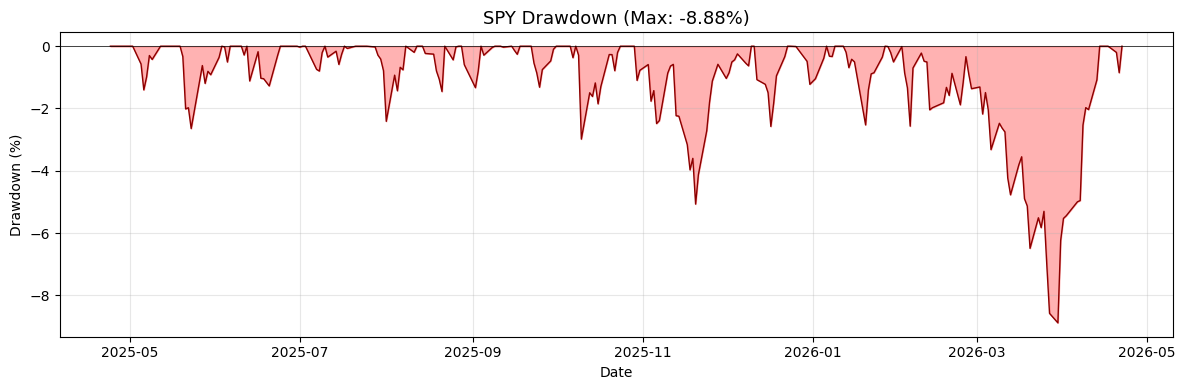

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(spy.index, spy['drawdown']*100, 0, 
                color='red', alpha=0.3, label='Drawdown')
ax.plot(spy.index, spy['drawdown']*100, color='darkred', linewidth=1)
ax.set_title(f'SPY Drawdown (Max: {max_drawdown*100:.2f}%)', fontsize=13)
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.grid(alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [35]:
downside_ret = daily_ret[daily_ret < 0]
downside_std = downside_ret.std() * np.sqrt(252)
sortino = (ann_return - risk_free) / downside_std
print(f"Sortino 比率: {sortino:.2f}")

Sortino 比率: 3.21


In [37]:
calmar = ann_return / abs(max_drawdown)
print(f"Calmar 比率: {calmar:.2f}")

Calmar 比率: 3.41


In [38]:
print("=" * 40)
print("     SPY 过去 1 年风险调整收益指标")
print("=" * 40)
print(f"年化收益率:   {ann_return*100:.2f}%")
print(f"年化波动率:   {ann_vol*100:.2f}%")
print(f"最大回撤:     {max_drawdown*100:.2f}%")
print(f"无风险利率:   {risk_free*100:.2f}%")
print("-" * 40)
print(f"夏普比率:     {sharpe:.2f}")
print(f"Calmar 比率:  {calmar:.2f}")
print(f"Sortino 比率: {sortino:.2f}")
print("=" * 40)

     SPY 过去 1 年风险调整收益指标
年化收益率:   30.34%
年化波动率:   12.58%
最大回撤:     -8.88%
无风险利率:   3.00%
----------------------------------------
夏普比率:     2.17
Calmar 比率:  3.41
Sortino 比率: 3.21
